> **@paxton** these were run outside the Docker container (Docker would not start locally), against
> a copy of `analysis_helpers` with `DATA_DIR` repointed at the repo — i.e. what the bind-mount does,
> with the notebook itself unmodified. Worth re-running in the container to confirm.

# Does simplifying the *episode's* trajectory predict which events participants leave out?

`rdp-analyses.ipynb` shows that simplifying a participant's immediate recall trajectory predicts
which events they stop recounting a week later. This notebook applies the same logic one step
earlier in the chain, to the episode itself: if watching and then recounting an episode is a
simplification of the same kind, then simplifying the *episode's* trajectory should predict which
episode events a participant leaves out of their immediate recounting.

Two versions of the question are asked, because they are not equivalent:

1. **Per participant.** For each participant, the episode trajectory is simplified at the tolerance
   whose simplification best aligns to that participant's immediate recall. Do the events
   simplification removes coincide with the events that participant never described?
2. **Across events.** Pooling over participants, are the events that simplification removes most
   often the events that the fewest participants described?

The first mirrors *Analysis 1* of `rdp-analyses.ipynb` exactly; the second is the group-level
statement, and is the weaker test — it has 18 events to work with rather than 53 participants.

Throughout, the episode and each recall are mean-centered on their shared centroid, as elsewhere in
the paper, and the episode's first and last events are excluded from every count: RDP retains the
endpoints of a trajectory by construction, so it can never predict that they are dropped.

## Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from scipy.stats import spearmanr

from analysis_helpers import Episode, Participant
from analysis_helpers.functions import (
    best_rdp_alignment,
    bootstrap_ci,
    events_recounted,
    hypergeom_mc_test,
    rdp,
    mean_center,
    show_source
)

## Functions

All of these live in `analysis_helpers.functions`; `rdp` and `best_rdp_alignment` are the same
implementations `rdp-analyses.ipynb` uses.

In [2]:
show_source(rdp)

In [3]:
show_source(best_rdp_alignment)

In [4]:
show_source(hypergeom_mc_test)

## Load data

In [5]:
atlep1 = Episode('atlep1')
participants = Participant.load_all()
n_events = len(atlep1.events)
n_participants = len(participants)

# RDP always retains a trajectory's endpoints, so the first and last episode
# events can never be predicted as dropped and are excluded from every count
POOL = set(range(1, n_events - 1))

# the same tolerance grid rdp-analyses.ipynb sweeps
EPSILONS = np.arange(0, 2, 0.01).round(2)

print(f'{n_participants} participants, {n_events} episode events '
      f'({len(POOL)} after excluding the endpoints)')

53 participants, 20 episode events (18 after excluding the endpoints)


## Simplify the episode to fit each participant's immediate recall

For each participant, the episode trajectory is simplified at every tolerance in turn and each
simplification is aligned to their immediate recall trajectory; the tolerance with the lowest
alignment cost wins. The events that tolerance removes are the events the model predicts the
participant will not describe. What actually happened is read off `event_matches`: an episode event
is "not described" if it appears nowhere in the participant's immediate recall.

Note that the tolerance is chosen using the recall trajectory that the prediction is then tested
against, exactly as in `rdp-analyses.ipynb`. The null below holds the number of predictions fixed,
so it controls for *how many* events are predicted, but not for that selection.

In [6]:
n_dropped = np.empty(n_participants, dtype=int)      # episode events never described
n_predicted = np.empty(n_participants, dtype=int)   # episode events RDP removed
n_hits = np.empty(n_participants, dtype=int)        # the overlap between them
best_epsilons = np.empty(n_participants)

for i, p in enumerate(participants):
    # center the episode and the recall on their shared centroid, to mitigate
    # person-specific register effects (idiolect, etc.)
    ep_events, imm_events = mean_center(atlep1.events, p.events['atlep1'])
    epsilon, kept, _ = best_rdp_alignment(ep_events, imm_events, EPSILONS)

    predicted = POOL - set(kept.tolist())
    dropped = POOL - set(p.event_matches['atlep1'].tolist())

    best_epsilons[i] = epsilon
    n_predicted[i] = len(predicted)
    n_dropped[i] = len(dropped)
    n_hits[i] = len(predicted & dropped)

print(f'best-fitting tolerance: median={np.median(best_epsilons):.2f}, '
      f'range=[{best_epsilons.min():.2f}, {best_epsilons.max():.2f}]')
print(f'episode events never described: mean={n_dropped.mean():.2f}, '
      f's.d.={n_dropped.std(ddof=1):.2f}')
print(f'episode events removed by simplification: mean={n_predicted.mean():.2f}, '
      f's.d.={n_predicted.std(ddof=1):.2f}')
print(f'participants for whom simplification predicted nothing: '
      f'{(n_predicted == 0).sum()} of {n_participants}')

best-fitting tolerance: median=0.00, range=[0.00, 0.82]
episode events never described: mean=2.72, s.d.=2.08
episode events removed by simplification: mean=1.15, s.d.=2.51
participants for whom simplification predicted nothing: 38 of 53


### Do the predicted and the actually-omitted events coincide?

Each participant supplies a draw without replacement from their own pool of episode events, so the
null distribution of the total hit count is built by simulation rather than solved in closed form.

The excess over the analytic hypergeometric mean gives an effect size with an interval on it. It is
reported twice: over all participants, and over only those whose best-fitting tolerance actually
removed something. The two differ a great deal here, because for most participants no simplification
at all aligned better than the full episode trajectory did — those participants make no prediction,
and so contribute exactly zero to both the observed total and every null total. The test is driven
entirely by the minority who do make one, and the restricted interval is the honest summary of how
large the effect is among them.

In [7]:
observed, expected, p, null_totals = hypergeom_mc_test(
    n_dropped, len(POOL) - n_dropped, n_predicted, n_hits
)

# per-participant excess over chance, for an effect size with an interval on it.
# The hypergeometric mean in closed form, rather than scipy's, which warns when
# a participant made no draws.
expected_each = n_dropped * n_predicted / len(POOL)
excess = n_hits - expected_each
predicted_something = n_predicted > 0

ci_lo, ci_hi = bootstrap_ci(excess, np.mean)
ci_lo_sub, ci_hi_sub = bootstrap_ci(excess[predicted_something], np.mean)

print(f'episode events correctly identified: {observed} in total, against '
      f'{expected:.1f} expected by chance, p={p:.4e} '
      f'(Monte Carlo test over {len(null_totals):,} hypergeometric draws)')
print(f'all participants:      mean excess={excess.mean():.3f} events, '
      f'95% CI [{ci_lo:.3f}, {ci_hi:.3f}], n={n_participants}')
print(f'those making a prediction: mean excess={excess[predicted_something].mean():.3f} events, '
      f'95% CI [{ci_lo_sub:.3f}, {ci_hi_sub:.3f}], n={predicted_something.sum()}')

episode events correctly identified: 22 in total, against 12.1 expected by chance, p=9.9990e-05 (Monte Carlo test over 10,000 hypergeometric draws)
all participants:      mean excess=0.187 events, 95% CI [0.058, 0.328], n=53
those making a prediction: mean excess=0.659 events, 95% CI [0.263, 1.033], n=15


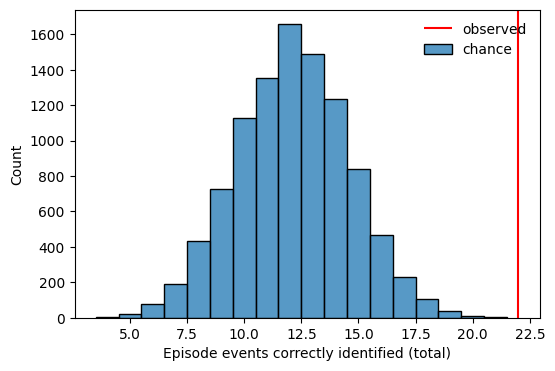

In [8]:
fig, ax = plt.subplots(1, figsize=(6, 4))
sns.histplot(null_totals, discrete=True, label='chance', ax=ax)
ax.set_ylim(ax.get_ylim())
ax.vlines(observed, *ax.get_ylim(), color='r', label='observed')
ax.set_xlabel('Episode events correctly identified (total)')
ax.legend(frameon=False)
plt.show()

## Across events: are the events simplification removes the ones fewest participants described?

This is the group-level version of the same question, and the form the claim takes when it is stated
about the episode rather than about an individual. Each episode event gets two numbers: how many
participants' simplifications removed it, and what proportion of participants described it. If
simplification is stripping out the forgettable parts of the episode, the two should trade off.

Spearman rather than Pearson, since the counts are small and bounded; two-sided, since nothing about
the geometry guarantees the sign. n here is the number of **episode events** (18 after excluding the
endpoints), not the number of participants.

In [9]:
interior = np.array(sorted(POOL))

# how many participants' simplifications removed each episode event
removal_counts = np.zeros(n_events, dtype=int)
for p in participants:
    ep_events, imm_events = mean_center(atlep1.events, p.events['atlep1'])
    _, kept, _ = best_rdp_alignment(ep_events, imm_events, EPSILONS)
    removal_counts[list(POOL - set(kept.tolist()))] += 1

# what proportion of participants described each episode event
imm_rates = np.array(
    [events_recounted(p.event_matches['atlep1'], n_events) for p in participants]
).mean(axis=0)

rho, p_rho = spearmanr(removal_counts[interior], imm_rates[interior])
print(f'times removed vs proportion describing: rho={rho.item():.3f}, '
      f'p={p_rho.item():.4f}, n={len(interior)} episode events')

times removed vs proportion describing: rho=-0.315, p=0.2023, n=18 episode events


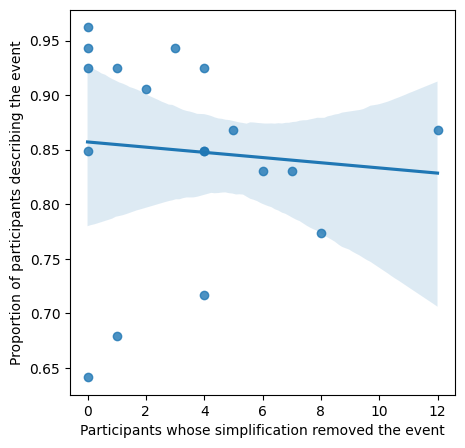

In [10]:
fig, ax = plt.subplots(1, figsize=(5, 5))
sns.regplot(x=removal_counts[interior], y=imm_rates[interior], ax=ax)
ax.set_xlabel('Participants whose simplification removed the event')
ax.set_ylabel('Proportion of participants describing the event')
ax.set_box_aspect(1)
plt.show()

The per-participant test is reliable and the across-events one is not, which is what the difference
in what they have to work with would predict: 53 participants against 18 events, and a group-level
correlation that has to survive the wide differences between participants in how much they described
at all. The result to report is the per-participant one; the across-events version is included
because it is the form the claim takes when it is stated about the episode as a whole, and it does
not hold in that form.